In [60]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective
from etl_pipeline_local import get_win_1x_table

sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARN)

load_dotenv()

True

In [2]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate
# TODO: analisi  univariata KPI più promettenti (Optional)

# 1. Load Data

In [61]:
# Bet setup
target_col = "win_1x"
odds_col: str = "dnb_1_odds"

# Load data
df_loaded = get_win_1x_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

def scale_odd(quota_orig):
    return (3/7) * quota_orig + 0.4857142857

# Feature Engineering
df[odds_col] = [scale_odd(x) for x in df['chance1x2_quote_current1']]
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[(df["chance1x2_quote_current1"] >= 1.9) & (df["chance1x2_quote_current1"] <= 2.6)]

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)


## 2. Define Parameters

In [ ]:
# Define features and relative step
feature_bins_map = {
    'chance1x2_chance_p1': 5,
    'chance1x2_bookkeeping_status': None,
    'chance1x2_comparison_affini': 250,
    'chance1x2_comparison_flashback': 250,
    'chance1x2_flashback_p1': 5,
    'evaluation_val1x2': None,
    'evaluation_valMetrica': None,
    'evaluation_valScala': None
}


objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 50, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: chance1x2_chance_p1
Search space: <IntegerArray>
[5, 10, 20, 25, 30, 35, 40, 45, 50, 55, 60]
Length: 11, dtype: Int64


Feature: chance1x2_bookkeeping_status
Search space: ['0' '1' '2' '3']


Feature: chance1x2_comparison_affini
Search space: <IntegerArray>
[0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750]
Length: 12, dtype: Int64


Feature: chance1x2_comparison_flashback
Search space: <IntegerArray>
[    0,   250,   500,   750,  1000,  1250,  1500,  1750,  2000,  2250,  2500,
  3750, 18250, 18500, 18750, 19000, 19250, 20500]
Length: 18, dtype: Int64


Feature: chance1x2_flashback_p1
Search space: <IntegerArray>
[20, 30, 35, 40, 45, 50, 55, <NA>]
Length: 8, dtype: Int64


Feature: evaluation_val1x2
Search space: ['224234' '55579' '916968' '917006' '918177' '960748' '961919']


Feature: evaluation_valMetrica
Search space: ['114521' '147930' '221599' '225586' '354214' '398418' '494608' '757193'
 '<NA>']


Feature: evaluation_valScala
Search space: 

## 3. Optimize

In [68]:
# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

[FrozenTrial(number=394, state=<TrialState.COMPLETE: 1>, values=[0.155853374199445], datetime_start=datetime.datetime(2026, 4, 3, 17, 34, 30, 241926), datetime_complete=datetime.datetime(2026, 4, 3, 17, 34, 30, 271241), params={'chance1x2_chance_p1_use_min': False, 'chance1x2_chance_p1_use_max': True, 'chance1x2_chance_p1_min': 10, 'chance1x2_chance_p1_max': 60, 'chance1x2_bookkeeping_status_cat_idx': 4, 'chance1x2_comparison_affini_use_min': True, 'chance1x2_comparison_affini_use_max': False, 'chance1x2_comparison_affini_min': 500, 'chance1x2_comparison_affini_max': 1000, 'chance1x2_comparison_flashback_use_min': False, 'chance1x2_comparison_flashback_use_max': True, 'chance1x2_comparison_flashback_min': 9750, 'chance1x2_comparison_flashback_max': 18500, 'chance1x2_flashback_p1_include_missing': False, 'chance1x2_flashback_p1_use_min': True, 'chance1x2_flashback_p1_use_max': False, 'chance1x2_flashback_p1_min': 40, 'chance1x2_flashback_p1_max': 50, 'evaluation_val1x2_cat_idx': 90, 'ev

## 4. Evaluate

In [70]:
# Create the test binned dataframe
return_threshold = -3.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -0.8500000002285724
Max return 4.5871428569
Score 0.155853374199445


Trial no. 1
Min return -1.3500000001714292
Max return 3.671428571257142
Score -0.006102670897594642


Trial no. 2
Min return -0.6500000000428572
Max return 2.185714285642857
Score -0.1408630697796407


Trial no. 3
Min return -2.721428571557144
Max return 3.2571428570142853
Score -0.26591926075074157


Trial no. 4
Min return -1.3500000001714292
Max return 3.671428571257142
Score -0.26931717657225673


Trial no. 5
Min return -1.3500000001714292
Max return 3.671428571257142
Score -0.26931717657225673


Trial no. 7
Min return -2.7500000000714286
Max return 4.538571428442857
Score -0.27828433973765654


Trial no. 8
Min return -2.721428571557144
Max return 3.2571428570142853
Score -0.28112367539361627


Trial no. 9
Min return -2.721428571557144
Max return 3.2571428570142853
Score -0.28112367539361627




Mean Train ROI: 0.1294919516986921
Train Accuracy: 0.8 (230/284)
Mean Test ROI: 0.11072948327127657
Test Accuracy: 0.8 (75/94)


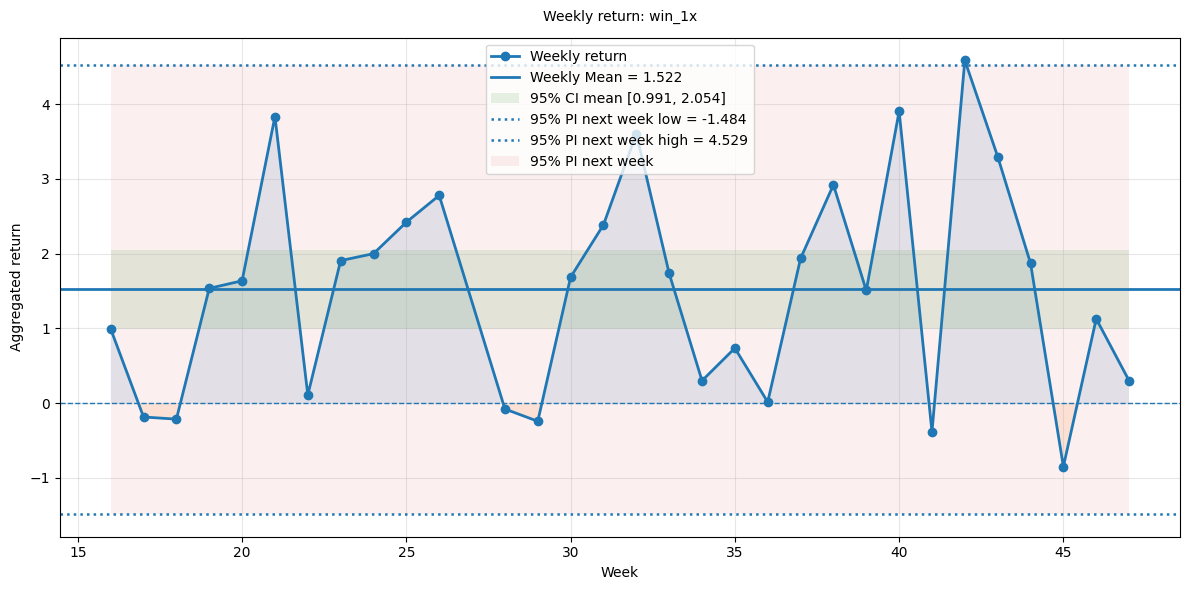

In [71]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [72]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 31/47 (0.66)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
win_1x,1.52,1.45,8.04,8.03,378,0.82


## 5. Save best Trials

In [74]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"dnb_1_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

Aggiunti: 1
Totale trial archiviati: 1
Best assoluto: 0.155853374199445 {'chance1x2_chance_p1_use_min': False, 'chance1x2_chance_p1_use_max': True, 'chance1x2_chance_p1_min': 10, 'chance1x2_chance_p1_max': 60, 'chance1x2_bookkeeping_status_cat_idx': 4, 'chance1x2_comparison_affini_use_min': True, 'chance1x2_comparison_affini_use_max': False, 'chance1x2_comparison_affini_min': 500, 'chance1x2_comparison_affini_max': 1000, 'chance1x2_comparison_flashback_use_min': False, 'chance1x2_comparison_flashback_use_max': True, 'chance1x2_comparison_flashback_min': 9750, 'chance1x2_comparison_flashback_max': 18500, 'chance1x2_flashback_p1_include_missing': False, 'chance1x2_flashback_p1_use_min': True, 'chance1x2_flashback_p1_use_max': False, 'chance1x2_flashback_p1_min': 40, 'chance1x2_flashback_p1_max': 50, 'evaluation_val1x2_cat_idx': 90, 'evaluation_valMetrica_cat_idx': 263, 'evaluation_valScala_cat_idx': 8}
